<a href="https://colab.research.google.com/github/akbar260/Notebooks/blob/main/LFM2_Resume_Parsing_Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading Libraries

In [1]:
!pip install unsloth
!pip install --no-deps transformers==4.55.0


  Using cached transformers-5.5.0-py3-none-any.whl.metadata (32 kB)
Using cached transformers-5.5.0-py3-none-any.whl (10.2 MB)
  Attempting uninstall: transformers
    Found existing installation: transformers 4.55.0
    Uninstalling transformers-4.55.0:
      Successfully uninstalled transformers-4.55.0
  Using cached transformers-4.55.0-py3-none-any.whl.metadata (39 kB)
Using cached transformers-4.55.0-py3-none-any.whl (11.3 MB)
  Attempting uninstall: transformers
    Found existing installation: transformers 5.5.0
    Uninstalling transformers-5.5.0:
      Successfully uninstalled transformers-5.5.0


In [2]:
!pip install transformers -U

  Using cached transformers-5.15.0-py3-none-any.whl.metadata (32 kB)
Using cached transformers-5.15.0-py3-none-any.whl (11.7 MB)
  Attempting uninstall: transformers
    Found existing installation: transformers 4.55.0
    Uninstalling transformers-4.55.0:
      Successfully uninstalled transformers-4.55.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.8.10 requires transformers!=4.52.0,!=4.52.1,!=4.52.2,!=4.52.3,!=4.53.0,!=4.54.0,!=4.55.0,!=4.55.1,!=4.57.4,!=4.57.5,!=5.0.0,!=5.1.0,<=5.5.0,>=4.51.3, but you have transformers 5.15.0 which is incompatible.
unsloth 2026.8.15 requires transformers!=4.52.0,!=4.52.1,!=4.52.2,!=4.52.3,!=4.53.0,!=4.54.0,!=4.55.0,!=4.55.1,!=4.57.0,!=4.57.4,!=4.57.5,!=5.0.0,!=5.1.0,<=5.5.0,>=4.51.3, but you have transformers 5.15.0 which is incompatible.


# Loading Model and Adapters

In [4]:
from unsloth import FastModel
import torch
from datasets import Dataset
import pandas as pd
import ast
import json

fourbit_models = [
    "unsloth/LFM2-1.2B-unsloth-bnb-4bit",
    "unsloth/LFM2-700M-unsloth-bnb-4bit",
    "unsloth/LFM2-350M-unsloth-bnb-4bit",
    "unsloth/LFM2-2.6B-Exp",
    "unsloth/LFM2-1.2B",
    "unsloth/LFM2-700M",
    "unsloth/LFM2-350M",
]

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/LFM2-2.6B-Exp",  # largest dense LFM2 on the Hub, comparable to other 3B models
    dtype = None,
    max_seq_length = 2048,
    load_in_4bit = True,
    full_finetuning = False,
)

==((====))==  Unsloth 2026.8.15: Fast Lfm2 patching. Transformers: 5.15.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/266 [00:00<?, ?it/s]

In [5]:
model = FastModel.get_peft_model(
    model,
    finetune_vision_layers = False,
    finetune_language_layers = True,
    finetune_attention_modules = True,
    finetune_mlp_modules = True,
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
)

# Loading and Formatting Resume Parsing Dataset (Hugging Face)


In [7]:
from datasets import load_dataset

# sawarni99/resume-to-json-dataset: 601 resumes, pre-split train/validation/test,
# each row is a chat-style conversation: system (parser instructions) + user (raw resume text) + assistant (target JSON)
raw_dataset = load_dataset("sawarni99/resume-to-json-dataset")

train_dataset = raw_dataset["train"].rename_column("messages", "conversations")
eval_dataset = raw_dataset["validation"].rename_column("messages", "conversations")

def formatting_prompts_func(examples):
    texts = tokenizer.apply_chat_template(
        examples["conversations"],
        tokenize = False,
        add_generation_prompt = False,
    )
    return { "text" : [x.removeprefix(tokenizer.bos_token) for x in texts] }

train_dataset = train_dataset.map(formatting_prompts_func, batched = True)
eval_dataset = eval_dataset.map(formatting_prompts_func, batched = True)

# sanity check - inspect one formatted example
print(train_dataset[0]["text"])


<|im_start|>system
You are a resume parser. Extract information from the resume text provided and return it as a single valid JSON object.
OUTPUT RULES:
- Output ONLY the JSON object. No markdown fences, no explanations, no commentary before or after.
- Use exactly these keys, in this order, every time.
- For any missing string value, use an empty string "". For any missing array, use an empty array []. Never use null and never omit a key.
- All years (year, start_year, end_year) should be in the format YYYY or "Present" if currently employed or studying.
- Do not invent or infer any information. Only extract what is present in the resume text.

SCHEMA:
{
  "description": "",
  "education": [
    {
      "school_name": "",
      "year": "",
      "degree": ""
    }
  ],
  "skills": [],
  "experience": [
    {
      "company_name": "",
      "start_year": "",
      "end_year": "",
      "descriptions": []
    }
  ],
  "projects": [
    {
      "name": "",
      "description": ""
    }
 

# Initialzing Trainer

In [8]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = eval_dataset,
    args = SFTConfig(
        dataset_text_field = "text",
        per_device_train_batch_size = 8,
        gradient_accumulation_steps = 2,
        warmup_steps = 20,
        num_train_epochs = 5,
        learning_rate = 2e-4,
        logging_steps = 10,
        eval_strategy = "steps",
        eval_steps = 30,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        report_to = "none",
        save_steps = 150,
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/480 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/60 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [9]:
from unsloth.chat_templates import train_on_responses_only

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|im_start|>user\n",
    response_part = "<|im_start|>assistant\n",
)


Map:   0%|          | 0/480 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

# Starting Training

In [10]:
trainer_stats = trainer.train()

trainer.save_model("lfm2_resume_parser_finetuned")

from google.colab import files
import shutil

shutil.make_archive("lfm2_resume_parser_finetuned", 'zip', "lfm2_resume_parser_finetuned")
files.download("lfm2_resume_parser_finetuned.zip")


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 480 | Num Epochs = 5 | Total steps = 150
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 20,135,936 of 2,589,408,256 (0.78% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
30,0.009388,0.005818
60,0.001588,0.002906
90,0.000789,0.002619
120,0.000366,0.002506
150,0.000423,0.002488


Filter:   0%|          | 0/60 [00:00<?, ? examples/s]

Unsloth: Restored added_tokens_decoder metadata in trainer_output/checkpoint-150/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in lfm2_resume_parser_finetuned/tokenizer_config.json.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Plotting Training Losses

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.interpolate import make_interp_spline

# Pull actual logged training loss from this run (previous notebook had hardcoded
# numbers from an unrelated food-recipe run - these are real now)
log_history = trainer.state.log_history
steps = [entry["step"] for entry in log_history if "loss" in entry]
loss = [entry["loss"] for entry in log_history if "loss" in entry]

sns.set_style("whitegrid")


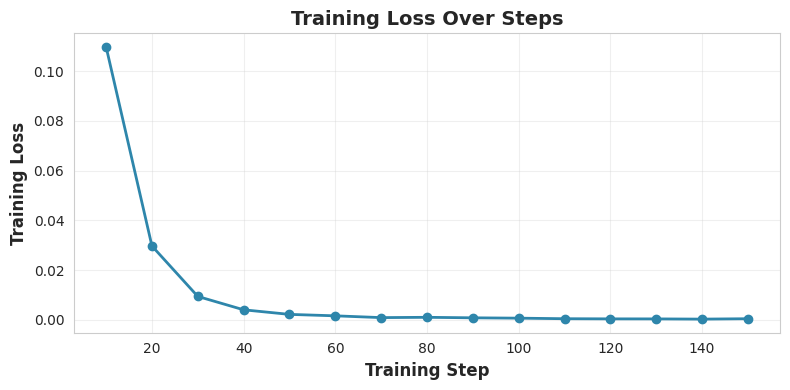

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(steps, loss, marker='o', linewidth=2, markersize=6, color='#2E86AB')
plt.xlabel('Training Step', fontsize=12, fontweight='bold')
plt.ylabel('Training Loss', fontsize=12, fontweight='bold')
plt.title('Training Loss Over Steps', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

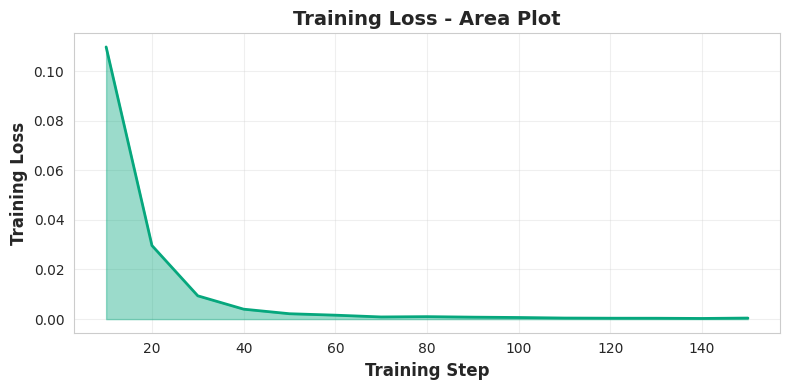

In [14]:
plt.figure(figsize=(8, 4))
plt.fill_between(steps, loss, alpha=0.4, color='#06A77D')
plt.plot(steps, loss, linewidth=2, color='#06A77D')
plt.xlabel('Training Step', fontsize=12, fontweight='bold')
plt.ylabel('Training Loss', fontsize=12, fontweight='bold')
plt.title('Training Loss - Area Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

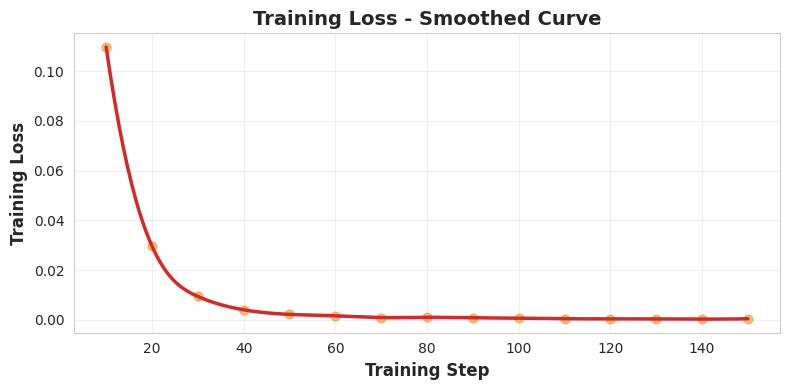

In [15]:
plt.figure(figsize=(8, 4))
x_smooth = np.linspace(min(steps), max(steps), 300)
spl = make_interp_spline(steps, loss, k=3)
y_smooth = spl(x_smooth)
plt.plot(x_smooth, y_smooth, linewidth=2.5, color='#D62828')
plt.scatter(steps, loss, s=40, alpha=0.5, color='#F77F00')
plt.xlabel('Training Step', fontsize=12, fontweight='bold')
plt.ylabel('Training Loss', fontsize=12, fontweight='bold')
plt.title('Training Loss - Smoothed Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

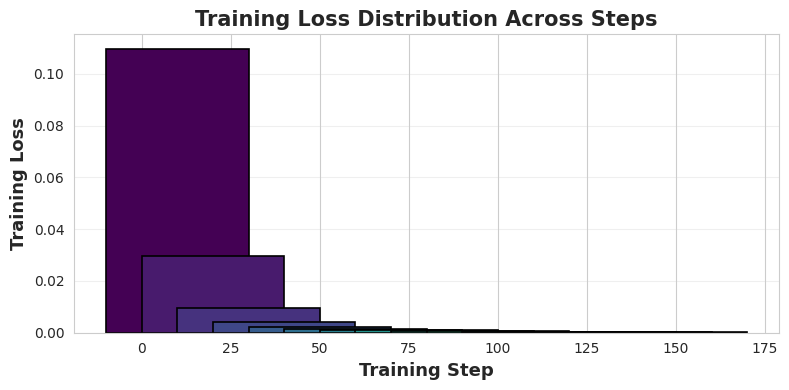

In [16]:
plt.figure(figsize=(8, 4))
colors = plt.cm.viridis(np.linspace(0, 1, len(steps)))
bars = plt.bar(steps, loss, width=40, color=colors, edgecolor='black', linewidth=1.2)
plt.xlabel('Training Step', fontsize=13, fontweight='bold')
plt.ylabel('Training Loss', fontsize=13, fontweight='bold')
plt.title('Training Loss Distribution Across Steps', fontsize=15, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Saving Adapters To Drive

In [17]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/lfm2_resume_parser_finetuned.zip /content/drive/MyDrive/


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import json

# ── Generation helper ──────────────────────────────────────────
FastModel.for_inference(model)  # switch model into fast inference mode

def generate_json(model, tokenizer, resume_text, system_prompt):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": resume_text},
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")
    out = model.generate(inputs, max_new_tokens=800, temperature=0.1, do_sample=False)
    decoded = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
    return decoded.strip()

# Pull the exact system prompt the model was trained on (don't hand-type it —
# small mismatches in wording can hurt output quality on smaller fine-tunes)
system_prompt = raw_dataset["train"][0]["messages"][0]["content"]

# ── Sample resumes ──────────────────────────────────────────────
sample_resumes = [
    # 1. Software engineer - clean, well-structured
    """Sarah Chen
sarah.chen.dev@email.com | (415) 555-0192 | San Francisco, CA
LinkedIn: linkedin.com/in/sarahchen

SUMMARY
Backend engineer with 6 years of experience building distributed systems in Python and Go. Focused on payments infrastructure and API reliability.

EXPERIENCE
Senior Software Engineer — Stripe (Jan 2022 - Present)
- Led migration of payment reconciliation service from monolith to microservices, reducing latency by 40%
- Mentored 3 junior engineers on distributed systems design
- Tech stack: Go, PostgreSQL, Kafka, Kubernetes

Software Engineer — Square (Jul 2019 - Dec 2021)
- Built fraud detection pipeline processing 2M+ transactions/day
- Tech stack: Python, Redis, AWS

EDUCATION
B.S. Computer Science, UC Berkeley, 2019

SKILLS
Python, Go, PostgreSQL, Kafka, Docker, Kubernetes, AWS, System Design
""",

    # 2. Marketing - non-technical, tests generalization outside training domain
    """MICHAEL TORRES
Digital Marketing Manager
michael.torres99@gmail.com | Chicago, IL | 312-555-0147

PROFESSIONAL SUMMARY
Results-driven marketing manager with 8+ years growing DTC brands through performance marketing and content strategy.

WORK HISTORY

Marketing Manager, Bloom & Co (2020-Present)
Grew email list from 12K to 95K subscribers. Managed $500K annual paid social budget across Meta and TikTok, achieving 3.2x ROAS. Oversaw team of 4.

Marketing Coordinator, Urban Outfitters (2017-2020)
Ran influencer partnership program, coordinated with 50+ creators. Assisted in launching seasonal campaigns.

EDUCATION
BA Marketing, University of Illinois Urbana-Champaign — 2017

CERTIFICATIONS
Google Analytics Certified, Meta Blueprint Certified

Skills: SEO, Paid Social, Email Marketing (Klaviyo), Content Strategy, Adobe Creative Suite
""",

    # 3. Nurse - short, sparse formatting, tests robustness on thin data
    """Priya Nair, RN
priya.nair.rn@outlook.com
(646) 555-0183

EXPERIENCE
- ICU Nurse, NewYork-Presbyterian Hospital, 2021-present
- Staff Nurse, Mount Sinai, 2018-2021

EDUCATION
BSN, Hunter College, 2018

LICENSES
RN License NY, BLS, ACLS Certified
""",

    # 4. New grad - minimal experience, tests handling of sparse/empty sections
    """Jordan Kim
jordan.kim.grad@email.com | Austin, TX | 512-555-0176

EDUCATION
B.S. Data Science, University of Texas at Austin
Expected Graduation: May 2026
GPA: 3.8/4.0

PROJECTS
Customer Churn Predictor - Built XGBoost model achieving 87% accuracy on telecom churn dataset. Deployed via Streamlit.

Sentiment Analysis Tool - Fine-tuned DistilBERT on Twitter data for real-time sentiment scoring.

SKILLS
Python, SQL, scikit-learn, Pandas, PyTorch, Tableau

INTERNSHIP
Data Analytics Intern, Dell Technologies, Summer 2025
Cleaned and analyzed sales datasets, built dashboards used by regional sales team.
""",
]

# ── Run inference and print results ──────────────────────────────
for i, resume in enumerate(sample_resumes):
    print(f"=== Sample {i+1} ===")
    output = generate_json(model, tokenizer, resume, system_prompt)
    try:
        parsed = json.loads(output)
        print(json.dumps(parsed, indent=2))
    except json.JSONDecodeError:
        print("⚠️ INVALID JSON:")
        print(output)
    print()

=== Sample 1 ===


Both `max_new_tokens` (=800) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=800) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{
  "description": "Backend engineer with 6 years of experience building distributed systems in Python and Go. Focused on payments infrastructure and API reliability.",
  "education": [
    {
      "school_name": "UC Berkeley",
      "year": "2019",
      "degree": "B.S. Computer Science"
    }
  ],
  "skills": [
    "Python",
    "Go",
    "PostgreSQL",
    "Kafka",
    "Docker",
    "Kubernetes",
    "AWS",
    "System Design"
  ],
  "experience": [
    {
      "company_name": "Stripe",
      "start_year": "2022",
      "end_year": "Present",
      "descriptions": [
        "Led migration of payment reconciliation service from monolith to microservices, reducing latency by 40%",
        "Mentored 3 junior engineers on distributed systems design"
      ]
    },
    {
      "company_name": "Square",
      "start_year": "2019",
      "end_year": "2021",
      "descriptions": [
        "Built fraud detection pipeline processing 2M+ transactions/day"
      ]
    }
  ],
  "projects": [],
 

Both `max_new_tokens` (=800) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{
  "description": "Results-driven marketing manager with 8+ years growing DTC brands through performance marketing and content strategy.",
  "education": [
    {
      "school_name": "University of Illinois Urbana-Champaign",
      "year": "2017",
      "degree": "BA Marketing"
    }
  ],
  "skills": [
    "SEO",
    "Paid Social",
    "Email Marketing (Klaviyo)",
    "Content Strategy",
    "Adobe Creative Suite"
  ],
  "experience": [
    {
      "company_name": "Bloom & Co",
      "start_year": "2020",
      "end_year": "Present",
      "descriptions": [
        "Grew email list from 12K to 95K subscribers.",
        "Managed $500K annual paid social budget across Meta and TikTok, achieving 3.2x ROAS.",
        "Oversaw team of 4."
      ]
    },
    {
      "company_name": "Urban Outfitters",
      "start_year": "2017",
      "end_year": "2020",
      "descriptions": [
        "Ran influencer partnership program, coordinated with 50+ creators.",
        "Assisted in launching seas

Both `max_new_tokens` (=800) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{
  "description": "",
  "education": [
    {
      "school_name": "Hunter College",
      "year": "2018",
      "degree": "BSN"
    }
  ],
  "skills": [],
  "experience": [
    {
      "company_name": "NewYork-Presbyterian Hospital",
      "start_year": "2021",
      "end_year": "Present",
      "descriptions": []
    },
    {
      "company_name": "Mount Sinai",
      "start_year": "2018",
      "end_year": "2021",
      "descriptions": []
    }
  ],
  "projects": [],
  "certifications": [
    {
      "name": "RN License NY",
      "institute_name": "",
      "description": ""
    },
    {
      "name": "BLS",
      "institute_name": "",
      "description": ""
    },
    {
      "name": "ACLS",
      "institute_name": "",
      "description": ""
    }
  ]
}

=== Sample 4 ===
{
  "description": "",
  "education": [
    {
      "school_name": "University of Texas at Austin",
      "year": "2026",
      "degree": "B.S. Data Science"
    }
  ],
  "skills": [
    "Python",
    "SQL",
   

In [24]:
import re
from datetime import date
from dateutil.relativedelta import relativedelta

def parse_year(y_str):
    """Parses a year-only value like '2022' or 'Present'."""
    if not y_str:
        return None
    y_str = str(y_str).strip()
    if y_str.lower() in ("present", "current", "ongoing", "now", "till date", "to date"):
        return date.today()
    match = re.search(r'\d{4}', y_str)
    if match:
        return date(int(match.group()), 1, 1)  # Jan 1 of that year (year-only precision)
    return None


def merge_intervals(intervals):
    intervals = sorted([iv for iv in intervals if iv[0] and iv[1] and iv[0] <= iv[1]], key=lambda x: x[0])
    if not intervals:
        return []
    merged = [intervals[0]]
    for start, end in intervals[1:]:
        last_start, last_end = merged[-1]
        if start <= last_end:
            merged[-1] = (last_start, max(last_end, end))
        else:
            merged.append((start, end))
    return merged


def extract_interval_from_job(job):
    """Matches this model's schema: start_year / end_year (year-only strings)."""
    start = parse_year(job.get("start_year"))
    end = parse_year(job.get("end_year"))
    if start and end:
        return start, end
    return None, None


def calculate_total_experience(resume_json, debug=False):
    experience_list = resume_json.get("experience") or resume_json.get("work_experience") or []

    intervals = []
    for job in experience_list:
        start, end = extract_interval_from_job(job)
        if debug:
            print(f"   {job.get('company_name')}: {job.get('start_year')}-{job.get('end_year')} -> parsed {start} to {end}")
        if start and end:
            intervals.append((start, end))

    merged = merge_intervals(intervals)

    total_months = 0
    for start, end in merged:
        delta = relativedelta(end, start)
        total_months += delta.years * 12 + delta.months

    years, months = divmod(total_months, 12)
    return years, months, total_months


# ── Example usage ──────────────────────────────
years, months, total_months = calculate_total_experience(parsed_resume, debug=True)
print(f"\nTotal work experience: {years} years, {months} months ({total_months} months total)")

# ── Example usage: resume 2 ──────────────────────────────
output_2 = generate_json(model, tokenizer, sample_resumes[1], system_prompt)
parsed_resume_2 = json.loads(output_2)
print(json.dumps(parsed_resume_2, indent=2))

years, months, total_months = calculate_total_experience(parsed_resume_2, debug=True)
print(f"\nTotal work experience: {years} years, {months} months ({total_months} months total)")

Both `max_new_tokens` (=800) and `max_length`(=128000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   Stripe: 2022-Present -> parsed 2022-01-01 to 2026-08-12
   Square: 2019-2021 -> parsed 2019-01-01 to 2021-01-01

Total work experience: 6 years, 7 months (79 months total)
{
  "description": "Results-driven marketing manager with 8+ years growing DTC brands through performance marketing and content strategy.",
  "education": [
    {
      "school_name": "University of Illinois Urbana-Champaign",
      "year": "2017",
      "degree": "BA Marketing"
    }
  ],
  "skills": [
    "SEO",
    "Paid Social",
    "Email Marketing (Klaviyo)",
    "Content Strategy",
    "Adobe Creative Suite"
  ],
  "experience": [
    {
      "company_name": "Bloom & Co",
      "start_year": "2020",
      "end_year": "Present",
      "descriptions": [
        "Grew email list from 12K to 95K subscribers.",
        "Managed $500K annual paid social budget across Meta and TikTok, achieving 3.2x ROAS.",
        "Oversaw team of 4."
      ]
    },
    {
      "company_name": "Urban Outfitters",
      "start_yea